In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RetailDemandForecasting") \
    .master("spark://spark-master:7077") \
    .getOrCreate()

print("Spark Session Created")
print("Spark Version:", spark.version)

Spark Session Created
Spark Version: 3.1.1


In [3]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("hdfs://namenode:8020/data/retail/raw/train.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.printSchema()

root
 |-- date: string (nullable = true)
 |-- store: integer (nullable = true)
 |-- item: integer (nullable = true)
 |-- sales: integer (nullable = true)



In [5]:
print("Total Records:", df.count())

Total Records: 913000


In [6]:
df.show(10)

+----------+-----+----+-----+
|      date|store|item|sales|
+----------+-----+----+-----+
|2013-01-01|    1|   1|   13|
|2013-01-02|    1|   1|   11|
|2013-01-03|    1|   1|   14|
|2013-01-04|    1|   1|   13|
|2013-01-05|    1|   1|   10|
|2013-01-06|    1|   1|   12|
|2013-01-07|    1|   1|   10|
|2013-01-08|    1|   1|    9|
|2013-01-09|    1|   1|   12|
|2013-01-10|    1|   1|    9|
+----------+-----+----+-----+
only showing top 10 rows



In [7]:
from pyspark.sql.functions import col, sum

df.select(
    sum(col("date").isNull().cast("int")).alias("null_dates"),
    sum(col("store").isNull().cast("int")).alias("null_stores"),
    sum(col("item").isNull().cast("int")).alias("null_items"),
    sum(col("sales").isNull().cast("int")).alias("null_sales")
).show()

+----------+-----------+----------+----------+
|null_dates|null_stores|null_items|null_sales|
+----------+-----------+----------+----------+
|         0|          0|         0|         0|
+----------+-----------+----------+----------+



In [8]:
print("Total Records:", df.count())
print("Distinct Records:", df.distinct().count())

Total Records: 913000
Distinct Records: 913000


In [9]:
from pyspark.sql.functions import to_date, year, month, dayofmonth, dayofweek

df = df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))

df = df.withColumn("year", year(col("date")))
df = df.withColumn("month", month(col("date")))
df = df.withColumn("day", dayofmonth(col("date")))
df = df.withColumn("day_of_week", dayofweek(col("date")))

df.printSchema()

root
 |-- date: date (nullable = true)
 |-- store: integer (nullable = true)
 |-- item: integer (nullable = true)
 |-- sales: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)



In [10]:
df.show(10)

+----------+-----+----+-----+----+-----+---+-----------+
|      date|store|item|sales|year|month|day|day_of_week|
+----------+-----+----+-----+----+-----+---+-----------+
|2013-01-01|    1|   1|   13|2013|    1|  1|          3|
|2013-01-02|    1|   1|   11|2013|    1|  2|          4|
|2013-01-03|    1|   1|   14|2013|    1|  3|          5|
|2013-01-04|    1|   1|   13|2013|    1|  4|          6|
|2013-01-05|    1|   1|   10|2013|    1|  5|          7|
|2013-01-06|    1|   1|   12|2013|    1|  6|          1|
|2013-01-07|    1|   1|   10|2013|    1|  7|          2|
|2013-01-08|    1|   1|    9|2013|    1|  8|          3|
|2013-01-09|    1|   1|   12|2013|    1|  9|          4|
|2013-01-10|    1|   1|    9|2013|    1| 10|          5|
+----------+-----+----+-----+----+-----+---+-----------+
only showing top 10 rows



In [11]:
store_sales = df.groupBy("store") \
    .sum("sales") \
    .withColumnRenamed("sum(sales)", "total_sales") \
    .orderBy("total_sales", ascending=False)

store_sales.show()

+-----+-----------+
|store|total_sales|
+-----+-----------+
|    2|    6120128|
|    8|    5856169|
|    3|    5435144|
|   10|    5360158|
|    9|    5025976|
|    4|    5012639|
|    1|    4315603|
|    5|    3631016|
|    6|    3627670|
|    7|    3320009|
+-----+-----------+



In [12]:
item_sales = df.groupBy("item") \
    .sum("sales") \
    .withColumnRenamed("sum(sales)", "total_sales") \
    .orderBy("total_sales", ascending=False)

item_sales.show(10)

+----+-----------+
|item|total_sales|
+----+-----------+
|  15|    1607442|
|  28|    1604713|
|  13|    1539621|
|  18|    1538876|
|  25|    1473334|
|  45|    1471467|
|  38|    1470330|
|  22|    1469971|
|  36|    1406548|
|   8|    1405108|
+----+-----------+
only showing top 10 rows



In [13]:
monthly_sales = df.groupBy("year", "month") \
    .sum("sales") \
    .withColumnRenamed("sum(sales)", "total_sales") \
    .orderBy("year", "month")

monthly_sales.show(60)

+----+-----+-----------+
|year|month|total_sales|
+----+-----+-----------+
|2013|    1|     454904|
|2013|    2|     459417|
|2013|    3|     617382|
|2013|    4|     682274|
|2013|    5|     763242|
|2013|    6|     795597|
|2013|    7|     855922|
|2013|    8|     766761|
|2013|    9|     689907|
|2013|   10|     656587|
|2013|   11|     692643|
|2013|   12|     506607|
|2014|    1|     525987|
|2014|    2|     529117|
|2014|    3|     704301|
|2014|    4|     788914|
|2014|    5|     882877|
|2014|    6|     906842|
|2014|    7|     989010|
|2014|    8|     885596|
|2014|    9|     785124|
|2014|   10|     758883|
|2014|   11|     800783|
|2014|   12|     578048|
|2015|    1|     552513|
|2015|    2|     551317|
|2015|    3|     730951|
|2015|    4|     824467|
|2015|    5|     926902|
|2015|    6|     937184|
|2015|    7|    1037350|
|2015|    8|     920401|
|2015|    9|     823332|
|2015|   10|     797253|
|2015|   11|     827645|
|2015|   12|     607572|
|2016|    1|     602439|


In [14]:
monthly_peak = monthly_sales.orderBy("total_sales", ascending=False)

monthly_peak.show(10)

+----+-----+-----------+
|year|month|total_sales|
+----+-----+-----------+
|2017|    7|    1171393|
|2016|    7|    1138718|
|2017|    6|    1064624|
|2015|    7|    1037350|
|2017|    8|    1026403|
|2016|    6|    1022664|
|2017|    5|    1020686|
|2014|    7|     989010|
|2016|    5|     988730|
|2016|    8|     981494|
+----+-----+-----------+
only showing top 10 rows



In [15]:
from pyspark.sql.functions import avg

average_sales = df.select(
    avg("sales").alias("average_sales")
)

average_sales.show()

+------------------+
|     average_sales|
+------------------+
|52.250286966046005|
+------------------+



In [16]:
store_sales.show(1)

+-----+-----------+
|store|total_sales|
+-----+-----------+
|    2|    6120128|
+-----+-----------+
only showing top 1 row



In [17]:
# Create forecasting features

from pyspark.sql.window import Window
from pyspark.sql.functions import lag, avg

window_spec = Window \
    .partitionBy("store", "item") \
    .orderBy("date")

df_model = df.withColumn(
    "lag_1",
    lag("sales", 1).over(window_spec)
)

df_model = df_model.withColumn(
    "lag_7",
    lag("sales", 7).over(window_spec)
)

rolling_window = Window \
    .partitionBy("store", "item") \
    .orderBy("date") \
    .rowsBetween(-7, -1)

df_model = df_model.withColumn(
    "rolling_7",
    avg("sales").over(rolling_window)
)

df_model.select(
    "date",
    "store",
    "item",
    "sales",
    "lag_1",
    "lag_7",
    "rolling_7"
).show(15)

+----------+-----+----+-----+-----+-----+------------------+
|      date|store|item|sales|lag_1|lag_7|         rolling_7|
+----------+-----+----+-----+-----+-----+------------------+
|2013-01-01|    3|  22|   50| null| null|              null|
|2013-01-02|    3|  22|   53|   50| null|              50.0|
|2013-01-03|    3|  22|   51|   53| null|              51.5|
|2013-01-04|    3|  22|   45|   51| null|51.333333333333336|
|2013-01-05|    3|  22|   46|   45| null|             49.75|
|2013-01-06|    3|  22|   62|   46| null|              49.0|
|2013-01-07|    3|  22|   28|   62| null|51.166666666666664|
|2013-01-08|    3|  22|   46|   28|   50|47.857142857142854|
|2013-01-09|    3|  22|   55|   46|   53|47.285714285714285|
|2013-01-10|    3|  22|   55|   55|   51| 47.57142857142857|
|2013-01-11|    3|  22|   54|   55|   45|48.142857142857146|
|2013-01-12|    3|  22|   71|   54|   46| 49.42857142857143|
|2013-01-13|    3|  22|   72|   71|   62|              53.0|
|2013-01-14|    3|  22| 

In [18]:
# Remove NULL forecasting features

df_model = df_model.dropna(
    subset=["lag_1", "lag_7", "rolling_7"]
)

print("Records after removing NULL values:", df_model.count())

Records after removing NULL values: 909500


In [19]:
# Create training and testing data

df_model.select("date").agg(
    {"date": "min"}
).show()

df_model.select("date").agg(
    {"date": "max"}
).show()

+----------+
| min(date)|
+----------+
|2013-01-08|
+----------+

+----------+
| max(date)|
+----------+
|2017-12-31|
+----------+



In [20]:
train = df_model.filter(
    year("date") < 2017
)

test = df_model.filter(
    year("date") == 2017
)

print("Training records:", train.count())
print("Testing records:", test.count())

Training records: 727000
Testing records: 182500


In [21]:
# Prepare features for the ML model

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["lag_1", "lag_7", "rolling_7"],
    outputCol="features"
)

train_model = assembler.transform(train)
test_model = assembler.transform(test)

train_model.select(
    "sales",
    "lag_1",
    "lag_7",
    "rolling_7",
    "features"
).show(10)

+-----+-----+-----+------------------+--------------------+
|sales|lag_1|lag_7|         rolling_7|            features|
+-----+-----+-----+------------------+--------------------+
|   46|   28|   50|47.857142857142854|[28.0,50.0,47.857...|
|   55|   46|   53|47.285714285714285|[46.0,53.0,47.285...|
|   55|   55|   51| 47.57142857142857|[55.0,51.0,47.571...|
|   54|   55|   45|48.142857142857146|[55.0,45.0,48.142...|
|   71|   54|   46| 49.42857142857143|[54.0,46.0,49.428...|
|   72|   71|   62|              53.0|    [71.0,62.0,53.0]|
|   43|   72|   28| 54.42857142857143|[72.0,28.0,54.428...|
|   39|   43|   46| 56.57142857142857|[43.0,46.0,56.571...|
|   51|   39|   55| 55.57142857142857|[39.0,55.0,55.571...|
|   52|   51|   55|              55.0|    [51.0,55.0,55.0]|
+-----+-----+-----+------------------+--------------------+
only showing top 10 rows



In [27]:
# Train a Random Forest model

from pyspark.ml.regression import RandomForestRegressor
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="sales",
    numTrees=50,
    maxDepth=10,
    seed=42
)

In [28]:
rf_model = rf.fit(train_model)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [29]:
# Make predictions

predictions = rf_model.transform(test_model)

predictions.select(
    "date",
    "store",
    "item",
    "sales",
    "prediction"
).show(20)

+----------+-----+----+-----+-----------------+
|      date|store|item|sales|       prediction|
+----------+-----+----+-----+-----------------+
|2017-01-01|    3|  22|   88|75.73102666585741|
|2017-01-02|    3|  22|   57| 67.7936023948767|
|2017-01-03|    3|  22|   77|67.61371808403413|
|2017-01-04|    3|  22|   60|69.88607494277913|
|2017-01-05|    3|  22|   74|74.35708840718443|
|2017-01-06|    3|  22|   78|78.22965867575869|
|2017-01-07|    3|  22|   69|75.19641758130773|
|2017-01-08|    3|  22|   75|78.72698959476016|
|2017-01-09|    3|  22|   55|60.42471398725519|
|2017-01-10|    3|  22|   65|67.97332877968053|
|2017-01-11|    3|  22|   70|65.49968260273005|
|2017-01-12|    3|  22|   69|72.20366942603995|
|2017-01-13|    3|  22|   77|73.48867156106775|
|2017-01-14|    3|  22|   56|72.20409796735967|
|2017-01-15|    3|  22|   96| 67.1643442560865|
|2017-01-16|    3|  22|   76|58.94340571103082|
|2017-01-17|    3|  22|   63|71.26798935794476|
|2017-01-18|    3|  22|   61|70.01628769

In [30]:
# Evaluate the forecasting model

from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
    labelCol="sales",
    predictionCol="prediction",
    metricName="rmse"
)

mae_evaluator = RegressionEvaluator(
    labelCol="sales",
    predictionCol="prediction",
    metricName="mae"
)

rmse = rmse_evaluator.evaluate(predictions)
mae = mae_evaluator.evaluate(predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 10.02145734937976
MAE: 7.599095968307437


In [31]:
# Save the prediction results to HDFS

final_predictions = predictions.select(
    "date",
    "store",
    "item",
    "sales",
    "prediction"
)

final_predictions.write \
    .mode("overwrite") \
    .option("header", "true") \
    .csv("hdfs://namenode:8020/data/retail/results/forecast_predictions")

print("Forecast results saved to HDFS")

Forecast results saved to HDFS


In [32]:
# Create the Actual vs Predicted graph

from pyspark.sql.functions import year, month, sum

monthly_prediction = predictions.groupBy(
    year("date").alias("year"),
    month("date").alias("month")
).agg(
    sum("sales").alias("actual_sales"),
    sum("prediction").alias("predicted_sales")
).orderBy("year", "month")

monthly_prediction.show(12)

+----+-----+------------+------------------+
|year|month|actual_sales|   predicted_sales|
+----+-----+------------+------------------+
|2017|    1|      617306| 628840.0769170912|
|2017|    2|      621369| 614646.8114021127|
|2017|    3|      822667| 804091.0601537395|
|2017|    4|      938862| 911507.3111248016|
|2017|    5|     1020686|1009397.5312432325|
|2017|    6|     1064624|1044803.7953948042|
|2017|    7|     1171393|1143805.1702450507|
|2017|    8|     1026403|1039347.3440645413|
|2017|    9|      935263| 940311.2233732408|
|2017|   10|      891160| 901964.8258699208|
|2017|   11|      928837| 917194.2239041636|
|2017|   12|      695170| 730121.5163360451|
+----+-----+------------+------------------+



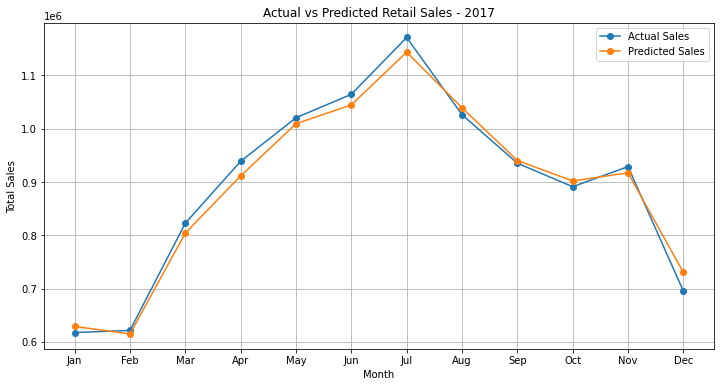

In [33]:
import matplotlib.pyplot as plt

plot_data = monthly_prediction.toPandas()

plot_data["month_name"] = plot_data["month"].map({
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
})

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["month_name"],
    plot_data["actual_sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    plot_data["month_name"],
    plot_data["predicted_sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Retail Sales - 2017")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.show()